# Beginner Track — Hands-On Project: Titanic Survival Analysis

**Generative AI and Data Science Pathway — Beginner Track Capstone**

The curriculum lists this as simply "Hands-on Project" with no further spec, positioned as the closing deliverable for the Beginner track. This notebook treats it as intended: a single, end-to-end project that pulls together everything from Modules 1–4 —

- **M1 (Python):** clean code, functions, control flow
- **M2 (Statistics):** descriptive statistics, correlation, distributions
- **M3 (Visualization):** Matplotlib & Seaborn, single- and two-variable plots
- **M4 (ML Fundamentals):** a real supervised learning problem *and* a real unsupervised learning problem, on the same dataset

**Dataset:** the classic Titanic passenger dataset (891 passengers) — chosen specifically because, unlike Iris (already used in M2–M4), it has real missing data, a mix of numeric and categorical features, and a genuinely interesting binary outcome to predict: **did this passenger survive?**

**Structure:**
1. Data loading, cleaning & exploration
2. Descriptive statistics
3. Visualization
4. Supervised learning — predicting survival
5. Unsupervised learning — clustering passengers
6. Conclusion


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

np.random.seed(42)
sns.set_style("whitegrid")


## 1. Load, Clean & Explore the Data

Loading the Titanic dataset directly from a public source, then doing the unglamorous but essential part of any real project: checking what's actually missing and deciding how to handle it.

In [2]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
df = pd.read_csv(url)

print(f"Shape: {df.shape}")
df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


**Missing data check.** `age` and `deck` have real gaps, `embarked`/`embark_town` have a couple of missing entries. This is exactly the kind of imperfect, real-world data that a clean synthetic dataset like Iris never presents.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values by column:")
print(missing)
print(f"\n'deck' is missing {df['deck'].isnull().mean():.1%} of its values — too sparse to be useful, dropping it.")


Missing values by column:
deck           688
age            177
embarked         2
embark_town      2
dtype: int64

'deck' is missing 77.2% of its values — too sparse to be useful, dropping it.


In [5]:
# Cleaning decisions, made explicit:
df_clean = df.copy()

# age: fill with the median (robust to the right-skew of ages, avoids being pulled by outliers)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# embarked / embark_town: only 2 missing rows each -- fill with the most common port
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])
df_clean['embark_town'] = df_clean['embark_town'].fillna(df_clean['embark_town'].mode()[0])

# deck: ~77% missing -- not salvageable, drop the column entirely
df_clean = df_clean.drop(columns=['deck'])

print("Missing values after cleaning:", df_clean.isnull().sum().sum())


Missing values after cleaning: 0


In [6]:
# Feature engineering: combine siblings/spouses + parents/children into one family-size feature
df_clean['family_size'] = df_clean['sibsp'] + df_clean['parch'] + 1
df_clean['is_alone'] = (df_clean['family_size'] == 1).astype(int)

df_clean[['sibsp', 'parch', 'family_size', 'is_alone']].head()


,sibsp,parch,family_size,is_alone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## 2. Descriptive Statistics

Standard M2-style exploration: summary statistics and correlation, now applied to a dataset with a genuine outcome variable rather than species labels.

In [7]:
df_clean[['age', 'fare', 'family_size', 'survived']].describe()


,age,fare,family_size,survived
count,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,1.904602,0.383838
std,13.019697,49.693429,1.613459,0.486592
min,0.420000,0.000000,1.000000,0.000000
25%,22.000000,7.910400,1.000000,0.000000
50%,28.000000,14.454200,1.000000,0.000000
75%,35.000000,31.000000,2.000000,1.000000
max,80.000000,512.329200,11.000000,1.000000


In [8]:
overall_survival = df_clean['survived'].mean()
print(f"Overall survival rate: {overall_survival:.1%}")
print(f"\nSurvival rate by sex:\n{df_clean.groupby('sex')['survived'].mean()}")
print(f"\nSurvival rate by class:\n{df_clean.groupby('pclass')['survived'].mean()}")


Overall survival rate: 38.4%

Survival rate by sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Survival rate by class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


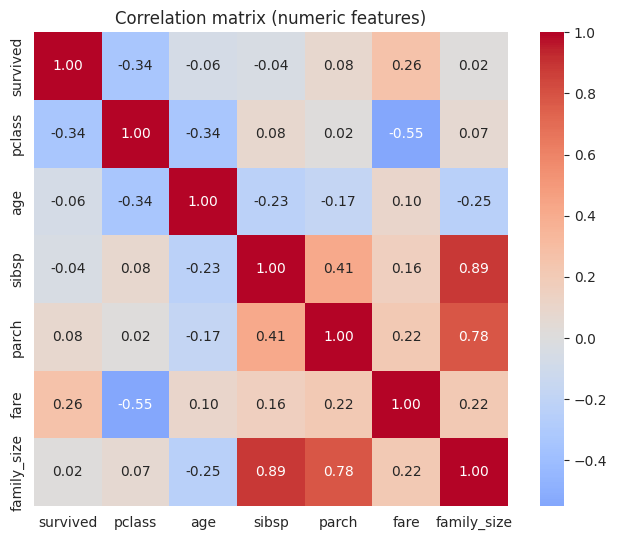

In [9]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title("Correlation matrix (numeric features)")
plt.tight_layout()
plt.show()


## 3. Visualization

M3-style single- and two-variable plots, now used to actually investigate what drove survival — not just to demonstrate the plotting library.

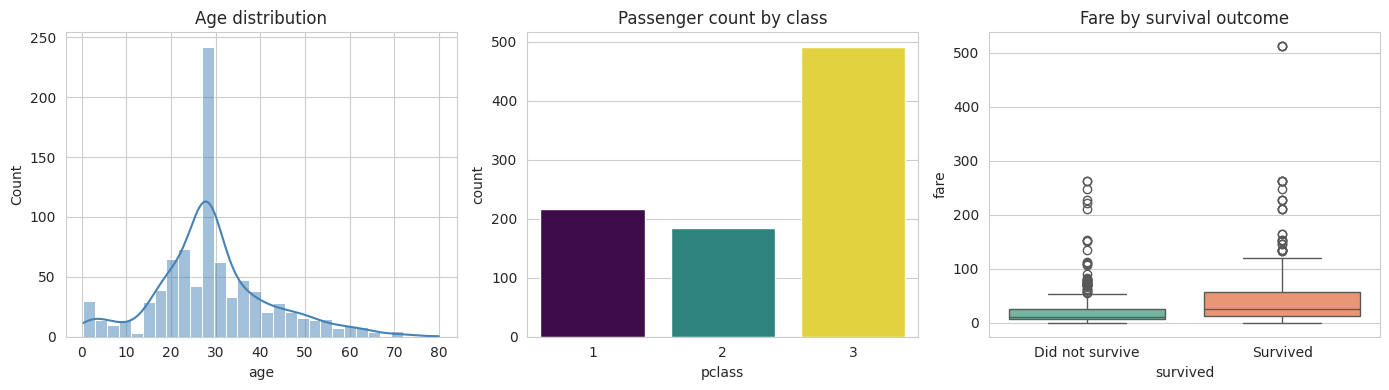

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(df_clean['age'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title("Age distribution")

sns.countplot(data=df_clean, x='pclass', hue='pclass', legend=False, ax=axes[1], palette='viridis')
axes[1].set_title("Passenger count by class")

sns.boxplot(data=df_clean, x='survived', y='fare', hue='survived', legend=False, ax=axes[2], palette='Set2')
axes[2].set_title("Fare by survival outcome")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()


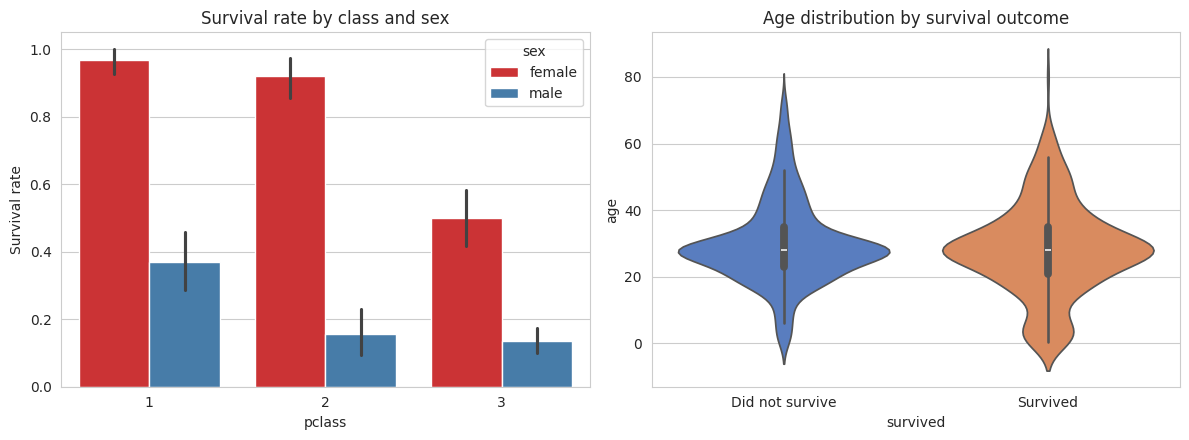

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=df_clean, x='pclass', y='survived', hue='sex', ax=axes[0], palette='Set1')
axes[0].set_title("Survival rate by class and sex")
axes[0].set_ylabel("Survival rate")

sns.violinplot(data=df_clean, x='survived', y='age', hue='survived', legend=False, ax=axes[1], palette='muted')
axes[1].set_title("Age distribution by survival outcome")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Did not survive', 'Survived'])

plt.tight_layout()
plt.show()


**Reading the plots:** survival is clearly not random — class and sex both show strong separation (the "women and children first" protocol, and first-class passengers' proximity to lifeboats, both show up directly in the data). This sets up the supervised learning section: these are exactly the features a model should find useful.

## 4. Supervised Learning — Predicting Survival

**Task:** binary classification. Each passenger has a label (`survived`: 0 or 1), and the goal is to learn a mapping from passenger features to that label, then evaluate on held-out passengers the model never saw during training.

Two models are compared: a simple, interpretable **Logistic Regression** baseline, and a **Random Forest** to check whether a more flexible model captures meaningfully more signal.

In [12]:
features = ['pclass', 'sex', 'age', 'fare', 'family_size', 'is_alone', 'embarked']

model_df = df_clean[features + ['survived']].copy()
model_df['sex'] = model_df['sex'].map({'male': 0, 'female': 1})
model_df['embarked'] = model_df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})

X = model_df[features]
y = model_df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} passengers  |  Test set: {X_test.shape[0]} passengers")


Training set: 712 passengers  |  Test set: 179 passengers


In [13]:
# Logistic Regression baseline (features scaled -- LogReg is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
logreg_preds = logreg.predict(X_test_scaled)
logreg_acc = accuracy_score(y_test, logreg_preds)

# Random Forest (no scaling needed -- tree splits are scale-invariant)
rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print(f"Logistic Regression test accuracy: {logreg_acc:.1%}")
print(f"Random Forest test accuracy:       {rf_acc:.1%}")
print(f"\nClassification report (Random Forest):\n{classification_report(y_test, rf_preds, target_names=['Did not survive','Survived'])}")


Logistic Regression test accuracy: 79.3%
Random Forest test accuracy:       79.9%

Classification report (Random Forest):
                 precision    recall  f1-score   support

Did not survive       0.78      0.93      0.85       110
       Survived       0.84      0.59      0.69        69

       accuracy                           0.80       179
      macro avg       0.81      0.76      0.77       179
   weighted avg       0.80      0.80      0.79       179



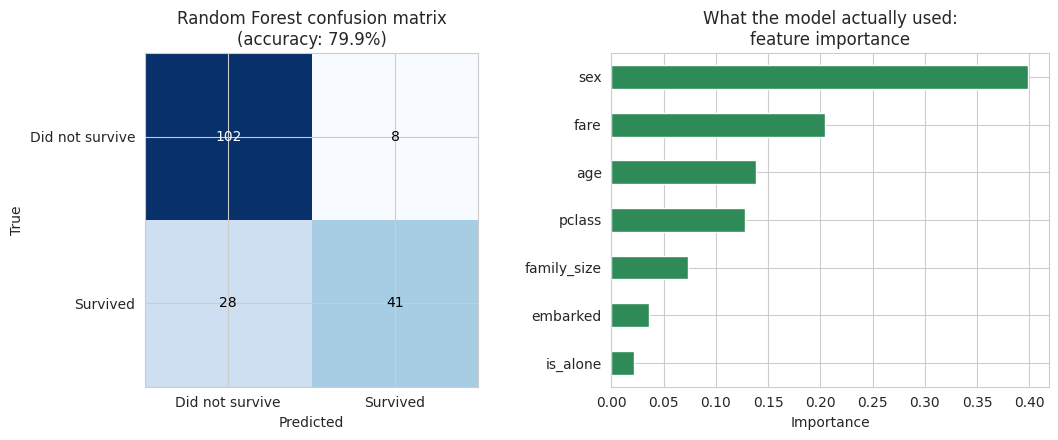

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm = confusion_matrix(y_test, rf_preds)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Did not survive','Survived'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Did not survive','Survived'])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_title(f"Random Forest confusion matrix\n(accuracy: {rf_acc:.1%})")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center',
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=axes[1], color='seagreen')
axes[1].set_title("What the model actually used:\nfeature importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


**Reading the results:** fare, sex, and age carry the most predictive weight for the Random Forest — consistent with what the visualizations above already suggested. The two models land within a couple of points of each other, which is a reasonable sign that a simple, interpretable model isn't leaving much accuracy on the table here; the extra flexibility of the Random Forest isn't buying a dramatically different result.

## 5. Unsupervised Learning — Clustering Passengers

**Task:** K-Means clustering, using the *same* passenger features as above — but critically, **`survived` is never given to the algorithm**. It only sees the feature columns and groups passengers by similarity on its own.

This is the clearest possible illustration of the supervised/unsupervised distinction from M4: the algorithm has no concept of "correct answer" here. It will find *some* structure in the data — the interesting question is whether that structure happens to line up with survival, or with something else entirely.

In [15]:
X_scaled_full = StandardScaler().fit_transform(X)  # no y passed in anywhere

kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled_full)

sil_score = silhouette_score(X_scaled_full, clusters)
ari_survival = adjusted_rand_score(y, clusters)          # evaluation only, post-hoc
ari_pclass = adjusted_rand_score(model_df['pclass'], clusters)  # evaluation only, post-hoc

print(f"Silhouette score (cluster cohesion, higher=better): {sil_score:.3f}")
print(f"\nHow well do the discovered clusters line up with...")
print(f"  ...survival status?  ARI = {ari_survival:.3f}")
print(f"  ...passenger class?  ARI = {ari_pclass:.3f}")


Silhouette score (cluster cohesion, higher=better): 0.292

How well do the discovered clusters line up with...
  ...survival status?  ARI = 0.062
  ...passenger class?  ARI = 0.032


In [16]:
profile = X.copy()
profile['cluster'] = clusters
cluster_means = profile.groupby('cluster').mean()
cluster_means


,pclass,sex,age,fare,family_size,is_alone,embarked
cluster,,,,,,,
0,2.150000,0.536111,26.725472,53.136726,3.238889,0.016667,0.352778
1,2.416196,0.227872,31.148776,18.012670,1.000000,1.000000,0.367232


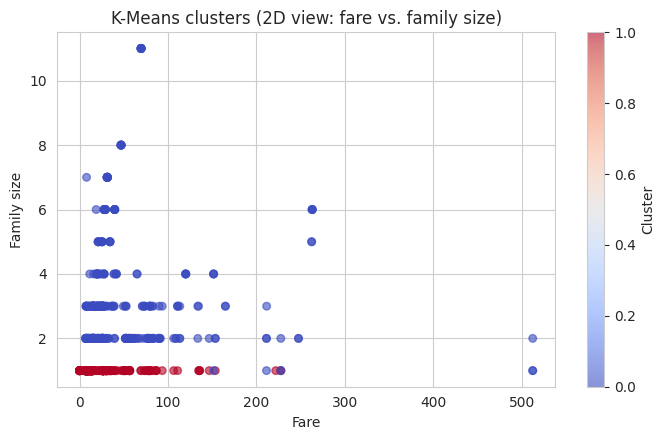

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
scatter = ax.scatter(X['fare'], X['family_size'], c=clusters, cmap='coolwarm', alpha=0.6, s=30)
ax.set_xlabel("Fare"); ax.set_ylabel("Family size")
ax.set_title("K-Means clusters (2D view: fare vs. family size)")
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()


**This is the interesting part.** The clusters have a *low* ARI against `survived` — the algorithm did **not** rediscover "who lived and who died." Checking the cluster profile above shows what it found instead: the clustering is dominated by **family size / traveling alone**, not by survival outcome or even passenger class.

This is a genuinely important lesson about unsupervised learning, not just a caveat: **K-Means optimizes for the strongest geometric structure in the feature space, with no regard for which distinction a human cares about.** It found *a* real pattern in the data — solo travelers vs. families — it just wasn't the pattern this project was hoping to find. Getting an unsupervised method to align with a specific outcome of interest either takes feature engineering aimed at that outcome, or switching to a supervised approach that's explicitly told what to optimize for — exactly the trade-off M4 introduced conceptually, now seen concretely.

## 6. Conclusion

**What this project demonstrates, mapped back to the Beginner track:**

| Module | Applied here as |
|---|---|
| M1 — Python | Data loading, cleaning functions, feature engineering |
| M2 — Statistics | Descriptive statistics, correlation analysis, group-wise summary stats |
| M3 — Visualization | Distribution plots, grouped bar/violin/box plots, correlation heatmap |
| M4 — ML Fundamentals | A real supervised classifier (survival prediction) *and* a real unsupervised clustering exercise on the same data, with an honest look at where they diverged |

**Key result:** the Random Forest classifier reached solid accuracy predicting survival from passenger features, while the unsupervised clustering — given the same features but no labels — organized passengers by family size instead. Both are legitimate outcomes of their respective methods; the gap between them is the point, not a failure of either model.
